# Proyecto - Preprocesamiento de Datos
---

- Saul Baltazar
- Jean Luka Terrazo
- Jose Wong

Este notebook contiene el script utilizado para la fase de preprocesamiento de datos para el desarrollo del proyecto.

El procesamiento se realizó en 2 etapas:

1.   Data Cleaning
  * Nivel I: Aspecto
  * Nivel II: Estructura
  * Nivel III: Exactitud
2. Data Transformation

In [ ]:
import pandas as pd
import numpy as np
import unicodedata
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Analisis Computacional de Datos/proyecto/dataset_analista_lima.csv")
df.head()

,url_detalle,cargo_especifico,empresa_nombre,ubicacion_provincia,salario_mensual_base,experiencia_requerida,menciones_tecnologia,tipo_contrato,jornada,educacion_minima,modalidad
0,https://pe.computrabajo.com/ofertas-de-trabajo...,Analista Jr de RyS / Rubro Financiero,Eurofirms Perú,"San Isidro, Lima",NaN,NaN,4,Contrato por Inicio o Incremento de Actividad,Completa,universitario,Presencial
1,https://pe.computrabajo.com/ofertas-de-trabajo...,Analista de Marketing Digital / VES,Grupo DN,"Villa El Salvador, Lima",NaN,3.0,5,Contrato por Necesidades del Mercado,Completa,universitario,Presencial
2,https://pe.computrabajo.com/ofertas-de-trabajo...,Analista de selección (Procesos bancarios y/o ...,Importante empresa del sector,"Lima, Lima",NaN,NaN,3,Contrato por Inicio o Incremento de Actividad,Completa,universitario,Remoto
3,https://pe.computrabajo.com/ofertas-de-trabajo...,Analista de Networking,"4,4OPTICAL NETWORKS S.A.C.","Surquillo, Lima",1600.0,1.0,4,Contrato por Necesidades del Mercado,Completa,técnico,Presencial
4,https://pe.computrabajo.com/ofertas-de-trabajo...,Analista de Nóminas,"4,5Grupo Educa_d","Santiago De Surco, Lima",NaN,3.0,4,Contrato por Inicio o Incremento de Actividad,Completa,universitario,Híbrido


---

## DATA CLEANING

### Nivel I: Aspecto

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   url_detalle            4000 non-null   object 
 1   cargo_especifico       4000 non-null   object 
 2   empresa_nombre         4000 non-null   object 
 3   ubicacion_provincia    4000 non-null   object 
 4   salario_mensual_base   1473 non-null   float64
 5   experiencia_requerida  1796 non-null   float64
 6   menciones_tecnologia   4000 non-null   int64  
 7   tipo_contrato          4000 non-null   object 
 8   jornada                3975 non-null   object 
 9   educacion_minima       4000 non-null   object 
 10  modalidad              4000 non-null   object 
dtypes: float64(2), int64(1), object(8)
memory usage: 343.9+ KB


**A) Identificador único**

Actualmente el dataframe solo cuenta con el indice que provee pandas, lo cual no es ideal. Lo bueno es que podemos encontrar un identificador único: el hash del link de la columna `url_detalle`.

Para el indentificador único de los registros del dataframe, se creará una columna que contenga dicho hash.

In [ ]:
cols = df.columns.tolist()
df['id_oferta'] = df['url_detalle'].str.extract(r'([A-F0-9]+)$')

cols = ['id_oferta'] + cols[1:]
df = df[cols]

df.head()

,id_oferta,cargo_especifico,empresa_nombre,ubicacion_provincia,salario_mensual_base,experiencia_requerida,menciones_tecnologia,tipo_contrato,jornada,educacion_minima,modalidad
0,8C39916808949D3F61373E686DCF3405,Analista Jr de RyS / Rubro Financiero,Eurofirms Perú,"San Isidro, Lima",NaN,NaN,4,Contrato por Inicio o Incremento de Actividad,Completa,universitario,Presencial
1,ED31FA4ABCE1FFAE61373E686DCF3405,Analista de Marketing Digital / VES,Grupo DN,"Villa El Salvador, Lima",NaN,3.0,5,Contrato por Necesidades del Mercado,Completa,universitario,Presencial
2,CDCE5090A62C406161373E686DCF3405,Analista de selección (Procesos bancarios y/o ...,Importante empresa del sector,"Lima, Lima",NaN,NaN,3,Contrato por Inicio o Incremento de Actividad,Completa,universitario,Remoto
3,CA0D5356E06046B061373E686DCF3405,Analista de Networking,"4,4OPTICAL NETWORKS S.A.C.","Surquillo, Lima",1600.0,1.0,4,Contrato por Necesidades del Mercado,Completa,técnico,Presencial
4,DF233DDD6B51CFF761373E686DCF3405,Analista de Nóminas,"4,5Grupo Educa_d","Santiago De Surco, Lima",NaN,3.0,4,Contrato por Inicio o Incremento de Actividad,Completa,universitario,Híbrido


**B) Nombre de columnas**

En cuanto a los nombres de columnas, tenemos los siguientes:

- `empresa_nombre`: se cambia el orden, a `nombre_empresa`, pero para hacerlo más simple, será solo `empresa`
- `ubicacion_provincia`: se cambia a `ciudad`. La explicación del nuevo nombre se verá en el nivel 2
- `cargo_especifico`: se cambia a `cargo`

In [ ]:
df.rename(columns={'cargo_especifico': 'cargo', 'empresa_nombre': 'empresa', 'ubicacion_provincia': 'ciudad'}, inplace=True)

df.head()

,id_oferta,cargo,empresa,ciudad,salario_mensual_base,experiencia_requerida,menciones_tecnologia,tipo_contrato,jornada,educacion_minima,modalidad
0,8C39916808949D3F61373E686DCF3405,Analista Jr de RyS / Rubro Financiero,Eurofirms Perú,"San Isidro, Lima",NaN,NaN,4,Contrato por Inicio o Incremento de Actividad,Completa,universitario,Presencial
1,ED31FA4ABCE1FFAE61373E686DCF3405,Analista de Marketing Digital / VES,Grupo DN,"Villa El Salvador, Lima",NaN,3.0,5,Contrato por Necesidades del Mercado,Completa,universitario,Presencial
2,CDCE5090A62C406161373E686DCF3405,Analista de selección (Procesos bancarios y/o ...,Importante empresa del sector,"Lima, Lima",NaN,NaN,3,Contrato por Inicio o Incremento de Actividad,Completa,universitario,Remoto
3,CA0D5356E06046B061373E686DCF3405,Analista de Networking,"4,4OPTICAL NETWORKS S.A.C.","Surquillo, Lima",1600.0,1.0,4,Contrato por Necesidades del Mercado,Completa,técnico,Presencial
4,DF233DDD6B51CFF761373E686DCF3405,Analista de Nóminas,"4,5Grupo Educa_d","Santiago De Surco, Lima",NaN,3.0,4,Contrato por Inicio o Incremento de Actividad,Completa,universitario,Híbrido


**C) Tipos de datos**

En lo que se ve del `df.info()`, los tipos de datos de las columnas corresponden a los datos que corresponden, excepto por una columna `experiencia_requerida`, que posee el tipo `float64`.

En las ofertas de trabajo de la plataforma, la experiencia requerida aparece en años enteros (nada de "6 meses de experiencia" o "X años y medio"), por lo que tiene sentido que esta columna tome un tipo `integer`. Sin embargo, esta columna presenta valores nulos, por lo que se manejan con el tipo `float64`.

La presencia de NaNs dentro de esta columna sí tienen un signicado relevante, por lo que, por mientras, se convertirá la columna a tipo `int64`. Más adelante se lidiará con los valores nulos de esta columna.

In [ ]:
df['experiencia_requerida'] = df['experiencia_requerida'].astype('Int64')

df.head()

,id_oferta,cargo,empresa,ciudad,salario_mensual_base,experiencia_requerida,menciones_tecnologia,tipo_contrato,jornada,educacion_minima,modalidad
0,8C39916808949D3F61373E686DCF3405,Analista Jr de RyS / Rubro Financiero,Eurofirms Perú,"San Isidro, Lima",NaN,<NA>,4,Contrato por Inicio o Incremento de Actividad,Completa,universitario,Presencial
1,ED31FA4ABCE1FFAE61373E686DCF3405,Analista de Marketing Digital / VES,Grupo DN,"Villa El Salvador, Lima",NaN,3,5,Contrato por Necesidades del Mercado,Completa,universitario,Presencial
2,CDCE5090A62C406161373E686DCF3405,Analista de selección (Procesos bancarios y/o ...,Importante empresa del sector,"Lima, Lima",NaN,<NA>,3,Contrato por Inicio o Incremento de Actividad,Completa,universitario,Remoto
3,CA0D5356E06046B061373E686DCF3405,Analista de Networking,"4,4OPTICAL NETWORKS S.A.C.","Surquillo, Lima",1600.0,1,4,Contrato por Necesidades del Mercado,Completa,técnico,Presencial
4,DF233DDD6B51CFF761373E686DCF3405,Analista de Nóminas,"4,5Grupo Educa_d","Santiago De Surco, Lima",NaN,3,4,Contrato por Inicio o Incremento de Actividad,Completa,universitario,Híbrido


### Nivel II: Estructura

Tenemos dos columnas problemáticas en cuanto al texto que contienen: `empresa` y `ciudad`.

- El caso del primero es que el scraper en ocasiones extrajo la calificación de la empresa dentro de la plataforma que aparece junto al nombre. Cabe aclarar que no todas las empresas contaban con dicha clasificación, por lo que tampoco se podría utilizar un análisis significativo con la calificación. Por ende, se borrarán las apariciones de calificaciones dentro del nombre de la empresa.

- En cuanto a la otra columna, puesto que se había fijado la ubicación a `Lima`, el formato de dicha columna consiste en `[ciudad], Lima`. Por ende, solo se conservará el nombre de la ciudad en la columna.

In [ ]:
df['empresa'] = df['empresa'].str.replace(r'^\d+,\d+', '', regex=True)
df['ciudad'] = df['ciudad'].str.split(',').str[0]

df.head()

,id_oferta,cargo,empresa,ciudad,salario_mensual_base,experiencia_requerida,menciones_tecnologia,tipo_contrato,jornada,educacion_minima,modalidad
0,8C39916808949D3F61373E686DCF3405,Analista Jr de RyS / Rubro Financiero,Eurofirms Perú,San Isidro,NaN,<NA>,4,Contrato por Inicio o Incremento de Actividad,Completa,universitario,Presencial
1,ED31FA4ABCE1FFAE61373E686DCF3405,Analista de Marketing Digital / VES,Grupo DN,Villa El Salvador,NaN,3,5,Contrato por Necesidades del Mercado,Completa,universitario,Presencial
2,CDCE5090A62C406161373E686DCF3405,Analista de selección (Procesos bancarios y/o ...,Importante empresa del sector,Lima,NaN,<NA>,3,Contrato por Inicio o Incremento de Actividad,Completa,universitario,Remoto
3,CA0D5356E06046B061373E686DCF3405,Analista de Networking,OPTICAL NETWORKS S.A.C.,Surquillo,1600.0,1,4,Contrato por Necesidades del Mercado,Completa,técnico,Presencial
4,DF233DDD6B51CFF761373E686DCF3405,Analista de Nóminas,Grupo Educa_d,Santiago De Surco,NaN,3,4,Contrato por Inicio o Incremento de Actividad,Completa,universitario,Híbrido


Ahora viene el *monstruo*: `cargo`. Los problemas con esta columna provienen de una suposición que se hizo en la fase de adquisición de datos:

En la plataforma, las ofertas de trabajo que inicialmente aparecían colocaban el cargo ofertado como el "título de la oferta", lo que tiene todo el sentido del mundo porque es de las primeras cosas que se fijan dentro de una oferta de trabajo.

Sin embargo, la forma de cómo nombrar el cargo no estaba estandarizado de alguna manera:
- Algunas ofertas solo incluían el cargo a ocupar (*Analista de Networking*)
- Otras ofertas abusaban de separadores para incluir información adicional, como el rubro, zona, etc (*Analista de Marketing Digital / VES*)
- Y también existían muchas variantes para nombrar un mismo cargo (*Asesor Comercial*, *ASESORA COMERCIAL*, *asesor/a comercial*)

Y lo más grave es que algunas empresas usaban este título para "marketearla" con frases como *urgente!!!*, *¡Gran oportunidad!*.

Para limpiar `cargo`, se realizará el siguiente plan:

In [ ]:
def reconstruir_cargo_v3(texto_sucio):
    if pd.isna(texto_sucio): return "Otros / No Especificado"

    txt = str(texto_sucio).lower()
    txt = unicodedata.normalize('NFKD', txt).encode('ASCII', 'ignore').decode('utf-8')

    mapa_roles = {
        r'\b(practicante|trainee|pasante)\b': 'Practicante',
        r'\b(jefe|gerente|manager|lider|head)\b': 'Jefe/Líder',
        r'\b(coordinador|supervisor)\b': 'Coordinador',
        r'\b(analista|business analyst|data analyst)\b': 'Analista',
        r'\b(asesor|consultor|ejecutivo|consejero|vendedor)\b': 'Asesor/Consultor',
        r'\b(desarrollador|programador|developer|architect)\b': 'Desarrollador',
        r'\b(tecnico|technician)\b': 'Técnico',
        r'\b(asistente|auxiliar|soporte|help desk|mesa de ayuda)\b': 'Asistente/Soporte',
        r'\b(promotor|impulsa)\b': 'Promotor',
        r'\b(auditor)\b': 'Auditor',
        r'\b(quimico)\b': 'Especialista'
    }

    rol_detectado = "Otros"
    for pattern, rol_std in mapa_roles.items():
        if re.search(pattern, txt):
            rol_detectado = rol_std
            break

    blacklist = ['bcp', 'manchay', 'santa anita', 'urgente', 'ingreso', 'lurin', 'callao']
    if rol_detectado == "Otros":
        if any(x in txt for x in blacklist) or len(txt) < 4:
            return "Otros / No Especificado"

    mapa_areas = {
        # Tecnología
        r'\b(datos?|data|bi|intelligence|sql|python|etl)\b': 'Datos / BI',
        r'\b(ti|sistemas|software|informatica|redes|computacion|aws|cloud|azure|java|net|stack|sap|odoo)\b': 'TI / Sistemas',
        r'\b(qa|testing|tester|calidad de software)\b': 'QA / Testing',

        # Finanzas / Admin
        r'\b(creditos?|cobranzas?|bancario|financiero|riesgos?|prestamos|caja|tesoreria)\b': 'Créditos y Cobranzas',
        r'\b(contable|contabilidad|tributario|impuestos|auditoria|costos|facturacion|nominas?|planillas?)\b': 'Contabilidad / Nóminas',

        # Comercial / Mkt
        r'\b(marketing|mkt|digital|ecommerce|trade|redes sociales|community)\b': 'Marketing',
        r'\b(comercial|ventas|negocios|b2b|b2c|clientes?|postventa|call center|atc)\b': 'Comercial / Ventas',

        # Operaciones / RRHH
        r'\b(rrhh|recursos humanos|seleccion|talento|humanos|bienestar|social)\b': 'RRHH',
        r'\b(logistica|almacen|compras|inventarios?|importaciones?|abastecimiento|transporte|distribucion)\b': 'Logística / Operaciones',
        r'\b(calidad|seguridad|ssoma|hse|medio ambiente)\b': 'Calidad / SSOMA',

        # Salud (Visto en tu data)
        r'\b(farmacia|farmaceutico|salud|clinica|medico|enfermeria)\b': 'Salud / Farmacia'
    }

    area_detectada = ""
    for pattern, area_std in mapa_areas.items():
        if re.search(pattern, txt):
            area_detectada = area_std
            break

    if rol_detectado == "Otros" and area_detectada == "":
        return "Otros / No Especificado"

    if area_detectada:
        return f"{rol_detectado} de {area_detectada}"
    else:
        return f"{rol_detectado} (General)"

In [ ]:
df['cargo_limpio'] = df['cargo'].apply(reconstruir_cargo_v3)

# Para recuperar el orden anterior
df = df.drop(columns=['cargo'])
df = df.rename(columns={'cargo_limpio': 'cargo'})

cols = df.columns.tolist()
df = df[['id_oferta', 'cargo'] + cols[1:-1]]

df.head()

,id_oferta,cargo,empresa,ciudad,salario_mensual_base,experiencia_requerida,menciones_tecnologia,tipo_contrato,jornada,educacion_minima,modalidad
0,8C39916808949D3F61373E686DCF3405,Analista de Créditos y Cobranzas,Eurofirms Perú,San Isidro,NaN,<NA>,4,Contrato por Inicio o Incremento de Actividad,Completa,universitario,Presencial
1,ED31FA4ABCE1FFAE61373E686DCF3405,Analista de Marketing,Grupo DN,Villa El Salvador,NaN,3,5,Contrato por Necesidades del Mercado,Completa,universitario,Presencial
2,CDCE5090A62C406161373E686DCF3405,Analista de Comercial / Ventas,Importante empresa del sector,Lima,NaN,<NA>,3,Contrato por Inicio o Incremento de Actividad,Completa,universitario,Remoto
3,CA0D5356E06046B061373E686DCF3405,Analista (General),OPTICAL NETWORKS S.A.C.,Surquillo,1600.0,1,4,Contrato por Necesidades del Mercado,Completa,técnico,Presencial
4,DF233DDD6B51CFF761373E686DCF3405,Analista de Contabilidad / Nóminas,Grupo Educa_d,Santiago De Surco,NaN,3,4,Contrato por Inicio o Incremento de Actividad,Completa,universitario,Híbrido


### Nivel III: Exactitud

En esta parte solo manejamos dos cosas: missing values y outliers

**A) Missing Values**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_oferta              4000 non-null   object 
 1   cargo                  4000 non-null   object 
 2   empresa                4000 non-null   object 
 3   ciudad                 4000 non-null   object 
 4   salario_mensual_base   1473 non-null   float64
 5   experiencia_requerida  1796 non-null   Int64  
 6   menciones_tecnologia   4000 non-null   int64  
 7   tipo_contrato          4000 non-null   object 
 8   jornada                3975 non-null   object 
 9   educacion_minima       4000 non-null   object 
 10  modalidad              4000 non-null   object 
dtypes: Int64(1), float64(1), int64(1), object(8)
memory usage: 347.8+ KB


Vemos que tenemos 3 columnas que presentan valores faltantes: `salario_mensual_base`, `experiencia_requerida` y `jornada`.

Afortunadamente, la presencia de valores nulos dentro de dichas columnas tienen un significado en sí que se puede cuantificar con un valor.

La razón de esto es la variabilidad de información presente dentro de las ofertas de trabajo scrapeadas de la plataforma elegida. En pocas palabras, había muy poca consistencia entre qué detalles estaban presentes dentro de las ofertas de trabajo:

- `salario_mensual_base`: varias de las ofertas de trabajo no daban una cifra precisa del salario ofertado, optando por indicar como "A discutir". Para la recolección, han sido captados como NAs.
- `experiencia_requerida`: existe una gran cantidad de requisitos mínimos que pueden o no exigir las empresas dentro de las ofertas laborales que publican. Dentro de estos está el número de años de experiencia previa. En este caso, un nulo es lo mismo que decir 0 años de experiencia requerida (o que la oferta no requiere experiencia alguna).
- `jornada`: en este caso es un simple error del parseo en la recolección. El detalle de indicar qué tipo de jornada sólo aparecía cuando no era "jornada completa", por lo que si no aparecía en la oferta, se asumía "jornada completa". Esto mismo se hará para rellenar los valores faltantes de esta columna.

In [ ]:
# Rellenando valores
df['experiencia_requerida'] = df['experiencia_requerida'].fillna(0).astype(int)
df['jornada'] = df['jornada'].fillna('Completa')

# Agregamos una simple columna de salario publicado
df['salario_publicado'] = df['salario_mensual_base'].notna().astype(int)

# Reordenando para colocarlo al costado de la otra columna de salario
cols = df.columns.tolist()
df = df[cols[:5] + ['salario_publicado'] + cols[5:-1]]
df.head()

,id_oferta,cargo,empresa,ciudad,salario_mensual_base,salario_publicado,experiencia_requerida,menciones_tecnologia,tipo_contrato,jornada,educacion_minima,modalidad
0,8C39916808949D3F61373E686DCF3405,Analista de Créditos y Cobranzas,Eurofirms Perú,San Isidro,NaN,0,0,4,Contrato por Inicio o Incremento de Actividad,Completa,universitario,Presencial
1,ED31FA4ABCE1FFAE61373E686DCF3405,Analista de Marketing,Grupo DN,Villa El Salvador,NaN,0,3,5,Contrato por Necesidades del Mercado,Completa,universitario,Presencial
2,CDCE5090A62C406161373E686DCF3405,Analista de Comercial / Ventas,Importante empresa del sector,Lima,NaN,0,0,3,Contrato por Inicio o Incremento de Actividad,Completa,universitario,Remoto
3,CA0D5356E06046B061373E686DCF3405,Analista (General),OPTICAL NETWORKS S.A.C.,Surquillo,1600.0,1,1,4,Contrato por Necesidades del Mercado,Completa,técnico,Presencial
4,DF233DDD6B51CFF761373E686DCF3405,Analista de Contabilidad / Nóminas,Grupo Educa_d,Santiago De Surco,NaN,0,3,4,Contrato por Inicio o Incremento de Actividad,Completa,universitario,Híbrido


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_oferta              4000 non-null   object 
 1   cargo                  4000 non-null   object 
 2   empresa                4000 non-null   object 
 3   ciudad                 4000 non-null   object 
 4   salario_mensual_base   1473 non-null   float64
 5   salario_publicado      4000 non-null   int64  
 6   experiencia_requerida  4000 non-null   int64  
 7   menciones_tecnologia   4000 non-null   int64  
 8   tipo_contrato          4000 non-null   object 
 9   jornada                4000 non-null   object 
 10  educacion_minima       4000 non-null   object 
 11  modalidad              4000 non-null   object 
dtypes: float64(1), int64(3), object(8)
memory usage: 375.1+ KB


Puesto que tenemos más registros con salarios no publicados, hacer un recorte supondría reducir el tamaño del dataset a más de la mitad. Por ello, se creó una columna adicional para indicar si la oferta publicó salarios o no. Se conservará la columna de `salario_mensual_base` momentáneamente, en caso sea útil para algún análisis a futuro.

**B) Outliers**

De las variables no categóricas, tenemos solo 2 interesantes para analizar outliers: `salario_mensual_base` y `experiencia_requerida`.

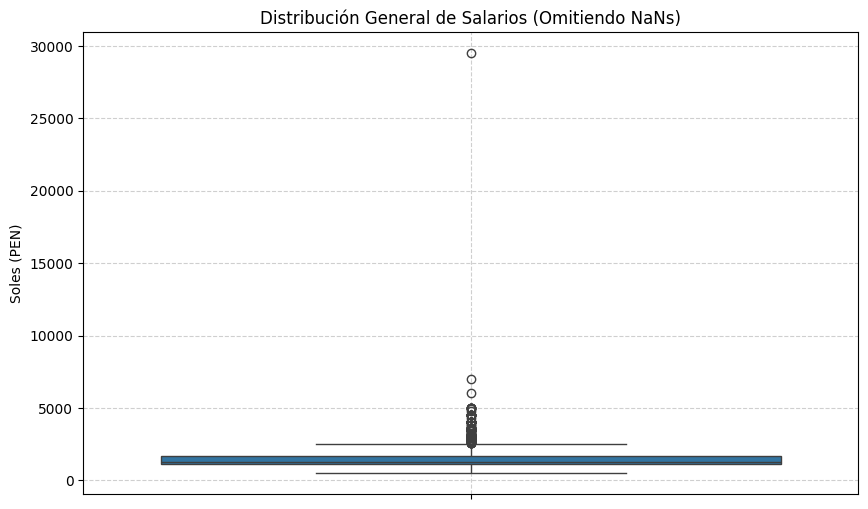

In [ ]:
# Boxplot de salarios
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['salario_mensual_base'])
plt.title('Distribución General de Salarios (Omitiendo NaNs)')
plt.ylabel('Soles (PEN)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [ ]:
limite = 5000
outliers_salario = df[df['salario_mensual_base'] > limite]
outliers_salario

,id_oferta,cargo,empresa,ciudad,salario_mensual_base,salario_publicado,experiencia_requerida,menciones_tecnologia,tipo_contrato,jornada,educacion_minima,modalidad
562,8292CD884F9B6D7461373E686DCF3405,Analista (General),Importante empresa del sector,San Miguel,7000.0,1,5,6,Contrato por Inicio o Incremento de Actividad,Completa,universitario,Presencial
870,2D593F5482408FAB61373E686DCF3405,Analista de TI / Sistemas,MODASA,Lima,6000.0,1,2,4,Contrato Intermitente,Completa,técnico,Híbrido
1353,A7C531978E94F85161373E686DCF3405,Asesor/Consultor (General),Reclutapro Pandapé,San Isidro,29500.0,1,0,3,Por horas,Completa,educación primaria,Presencial


Analizando cada uno de los outliers obtenidos para `salario_mensual_base`:

1. (Analista (General), sueldo de 7000 soles, 5 años de experiencia requerida): tiene sentido, los requisitos para tomar la oferta de trabajo son relativamente altos para corresponder a dicho sueldo.
2. (Analista de TI / Sistemas, sueldo de 6000 soles, 2 años de experiencia requerida): viendo el registro completo, es realista tener dicho salario con los requisitos que piden en la oferta.
3. (Asesor/Consultor (General), sueldo de 29500 soles, 0 años de experiencia requerida): definitivamente un outlier a eliminar, 0 sentido los requisitos para el salario más alto dentro del Dataframe.

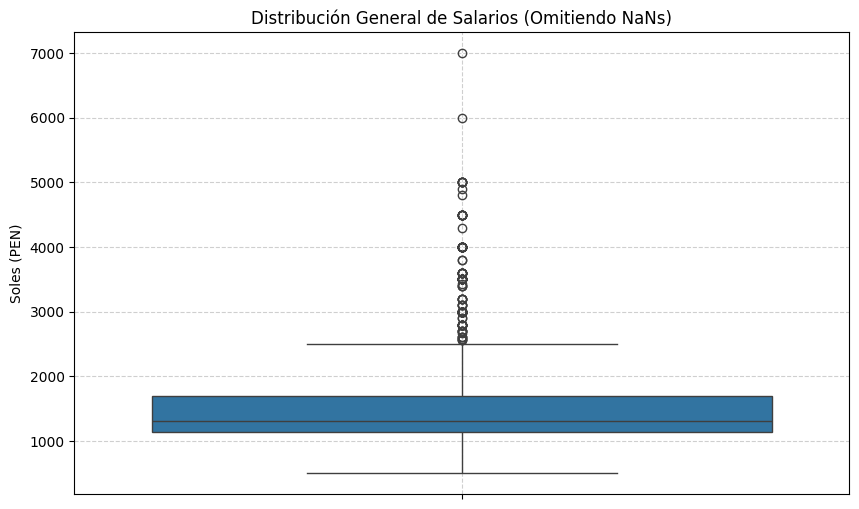

In [ ]:
# Eliminando el outlier
df.drop(1353, inplace=True)

plt.figure(figsize=(10, 6))
sns.boxplot(y=df['salario_mensual_base'])
plt.title('Distribución General de Salarios (Omitiendo NaNs)')
plt.ylabel('Soles (PEN)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Ahora la distribución de `salario_mensual_base` tiene más sentido. Continuando con el análisis de outliers sobre `experiencia_requerida`.

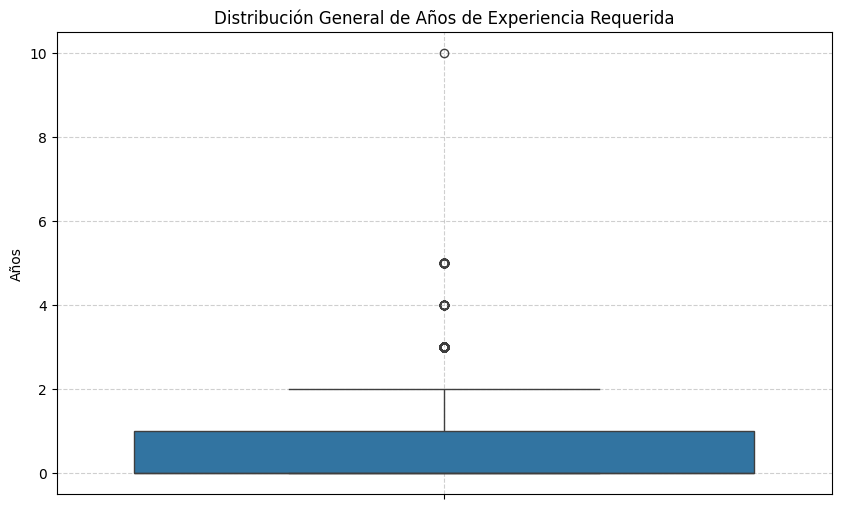

In [ ]:
# Bloxplot con experiencia_requerida

plt.figure(figsize=(10, 6))
sns.boxplot(y=df['experiencia_requerida'])
plt.title('Distribución General de Años de Experiencia Requerida')
plt.ylabel('Años')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [ ]:
limit_2 = 5

outlier_exp = df[df['experiencia_requerida'] > limit_2]
outlier_exp

,id_oferta,cargo,empresa,ciudad,salario_mensual_base,salario_publicado,experiencia_requerida,menciones_tecnologia,tipo_contrato,jornada,educacion_minima,modalidad
619,3D621C5EF6783F1F61373E686DCF3405,Analista de Datos / BI,Topstrategic S.A.C.,San Isidro,NaN,0,10,5,Contrato por Inicio o Incremento de Actividad,Completa,técnico,Híbrido


Analizando dicho outlier, un Analista de Datos / BI con 10 años de experiencia requerida es plausible. Es un indicador que la empresa busca un senior dentro de dicha posición, así que lo conservaremos.

---

## DATA TRANSFORMATION

Dentro de *Data Transformation*, analizaremos distintas columnas dentro del dataframe, con miras a crear nuevas columnas con información más util para el futuro análisis.

Las columnas candidato son las siguientes:

- `experiencia_requerida`: dentro del ambiente laboral, podemos dividir el nivel de experiencia dentro de un cargo en 4 campos: *trainee / junior*, *mid-level*, *senior* y *lead / expert*. Por lo que se discretizará esta variable usando *binning*.
- `educacion_minima`: existe una jerarquía dentro del nivel de educación, puesto que es más exigente pedir un educación universitaria que educación primaria. Es apropiado dar un encoding ordinal para representar estos niveles.
- `modalidad`: se aplicará one-hot encoding para representar las distintas modalidades de la oferta de trabajo. "Híbrido" tendría es_remoto=1 y es_presencial=1.
- `salario_mensual_base`: se segmentarán los salarios presentes en el dataframe para obtener 3 tercios.
- `jornada`: se agregará una flag que represente cuando la oferta de trabajo ofrezca una jornada Parcial.

In [ ]:
# Discretizando experiencia_requerida
bins_exp = [-1, 1, 3, 5, 100]
labels_exp = ['Junior', 'Mid-Level', 'Senior', 'Lead']

df['nivel_experiencia'] = pd.cut(df['experiencia_requerida'], bins=bins_exp, labels=labels_exp)

In [ ]:
# Encoding ordinal para educacion_minima
map_educacion = {'educación primaria': 1, 'educación secundaria': 2, 'técnico': 3, 'universitario': 4, 'maestría': 5}

df['educacion_minima_valor'] = df['educacion_minima'].str.lower().map(map_educacion).fillna(0)

In [ ]:
# Enconding para modalidad
mod = df['modalidad'].astype(str).str.lower()

df['es_remoto'] = mod.apply(lambda x: 1 if 'remoto' in x or 'híbrido' in x else 0)
df['es_presencial'] = mod.apply(lambda x: 1 if 'presencial' in x or 'híbrido' in x else 0)

In [ ]:
# Segmentación para salario_mensual_base

df['segmento_salarial'] = pd.qcut(df['salario_mensual_base'], q=3, labels=['Bajo', 'Medio', 'Alto'])

In [ ]:
# Flag para jornada

df['tiempo_parcial'] = df['jornada'].apply(lambda x: 1 if 'Parcial' in str(x) else 0)

In [ ]:
# Reordenando columnas

df = df[['id_oferta', 'cargo', 'empresa', 'ciudad', 'salario_publicado',
        'salario_mensual_base', 'segmento_salarial', 'experiencia_requerida',
        'nivel_experiencia', 'educacion_minima', 'educacion_minima_valor', 'modalidad',
        'es_remoto', 'es_presencial', 'tipo_contrato',
        'jornada', 'tiempo_parcial','menciones_tecnologia']]

df.head()

,id_oferta,cargo,empresa,ciudad,salario_publicado,salario_mensual_base,segmento_salarial,experiencia_requerida,nivel_experiencia,educacion_minima,educacion_minima_valor,modalidad,es_remoto,es_presencial,tipo_contrato,jornada,tiempo_parcial,menciones_tecnologia
0,8C39916808949D3F61373E686DCF3405,Analista de Créditos y Cobranzas,Eurofirms Perú,San Isidro,0,NaN,NaN,0,Junior,universitario,4,Presencial,0,1,Contrato por Inicio o Incremento de Actividad,Completa,0,4
1,ED31FA4ABCE1FFAE61373E686DCF3405,Analista de Marketing,Grupo DN,Villa El Salvador,0,NaN,NaN,3,Mid-Level,universitario,4,Presencial,0,1,Contrato por Necesidades del Mercado,Completa,0,5
2,CDCE5090A62C406161373E686DCF3405,Analista de Comercial / Ventas,Importante empresa del sector,Lima,0,NaN,NaN,0,Junior,universitario,4,Remoto,1,0,Contrato por Inicio o Incremento de Actividad,Completa,0,3
3,CA0D5356E06046B061373E686DCF3405,Analista (General),OPTICAL NETWORKS S.A.C.,Surquillo,1,1600.0,Alto,1,Junior,técnico,3,Presencial,0,1,Contrato por Necesidades del Mercado,Completa,0,4
4,DF233DDD6B51CFF761373E686DCF3405,Analista de Contabilidad / Nóminas,Grupo Educa_d,Santiago De Surco,0,NaN,NaN,3,Mid-Level,universitario,4,Híbrido,1,1,Contrato por Inicio o Incremento de Actividad,Completa,0,4


Con estas transformaciones quedaría finalizada la fase de preprocesamiento de datos. Queda como resultado un dataset preparado para el análisis.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3999 entries, 0 to 3999
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   id_oferta               3999 non-null   object  
 1   cargo                   3999 non-null   object  
 2   empresa                 3999 non-null   object  
 3   ciudad                  3999 non-null   object  
 4   salario_publicado       3999 non-null   int64   
 5   salario_mensual_base    1472 non-null   float64 
 6   segmento_salarial       1472 non-null   category
 7   experiencia_requerida   3999 non-null   int64   
 8   nivel_experiencia       3999 non-null   category
 9   educacion_minima        3999 non-null   object  
 10  educacion_minima_valor  3999 non-null   int64   
 11  modalidad               3999 non-null   object  
 12  es_remoto               3999 non-null   int64   
 13  es_presencial           3999 non-null   int64   
 14  tipo_contrato           3999 

In [ ]:
df.to_csv('dataset_analista_final_procesado.csv', index=False, encoding='utf-8')